# scTOP Vignette 1- Basics of Using a Source

In [3]:
# Load libraries
import pandas as pd  # Not actually used here but data structures are built with pandas so you may need for new operations
import plotly.io as pio
pio.renderers.default = 'notebook'
import sys
import os
os.chdir('/restricted/projectnb/crem-trainees/Kotton_Lab/Eitan/Vilker_Helper_Files/scTOP/vignettes') # Change to wherever your file is located
basisCollection = "../objects/BasisCollection.csv"  # Modify this file with your own basis names and file locations
datasetCollection = "../objects/DatasetCollection.csv"  # Modify this file with your own datasets and associated metadata
sys.path.append('../scripts')

# For if you want to edit the following libraries on the fly
%load_ext autoreload
%autoreload 1
%aimport SimilarityHelper
%aimport TopObject

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Negretti-Montoro Basis

In [6]:
# This function uses only the lung subset, but you can use top.load_basis("Negretti-Montoro", 50) to get other areas as well
mouseBasis = SimilarityHelper.loadBasis(basisName="Negretti-Montoro", basisCollection=basisCollection)

Loaded Negretti-Montoro basis!


## Load Test Dataset

In [7]:
Riemondy = TopObject.TopObject("Riemondy")

Setting AnnData object...
Setting AnnData...
Setting metadata and df...
Processing scTOP data...
Done processing!
Finished setup!


In [8]:
# Get overview of dataset parameters
print(Riemondy)

Attributes:
identifier: Riemondy
datasetCollection: /restricted/projectnb/crem-trainees/Kotton_Lab/Eitan/OutsidePaperObjects/DatasetCollection.csv
processed: ['ATI1expt1_AAACGGGAGTGTTTGC', 'ATI1expt1_AAAGTAGGTTCCACTC', 'ATI1expt1_AACCATGTCGAGAGCA', 'ATI1expt1_AACTCAGGTAAACCTC', 'ATI1expt1_AACTCTTCAAGCCCAC']...
cellTypeColumn: labeled_clusters
toKeep: [Basal, Injured Type II, Naive Type I, Naive Type II, Transdifferentiating Type II]...
toExclude: ['']
filePath: /restricted/projectnb/crem-trainees/Kotton_Lab/Eitan/OutsidePaperObjects/AnnData/Riemondy.h5ad
timeColumn: None
species: mouse
duplicates: False
raw: False
layer: None
comments: None
anndata: <class 'anndata._core.anndata.AnnData'>
metadata: ['orig.ident', 'sample_names', 'expt', 'new_expt_id', 'proportion.mito']...
annotations: ['Endothelial', 'Basal', 'Basal', 'Club', 'Basal']...
sortedCellTypes: [Basal, Cell Cycle Arrest Type II, Ciliary, Club, Endothelial]...
timeSortFunction: None
timesSorted: None
df: ['ATI1expt1_AAACGGGAG

In [9]:
# Project onto basis
Riemondy.project(mouseBasis, "Negretti-Montoro")

Projecting onto basis...
Finished projecting! 4475 genes were in both the source and basis.


index,ATI1expt1_AAACGGGAGTGTTTGC,ATI1expt1_AAAGTAGGTTCCACTC,ATI1expt1_AACCATGTCGAGAGCA,ATI1expt1_AACTCAGGTAAACCTC,ATI1expt1_AACTCTTCAAGCCCAC,ATI1expt1_AACTCTTGTATAATGG,ATI1expt1_AACTCTTGTCGTTGTA,ATI1expt1_AACTTTCGTAAGGGAA,ATI1expt1_AAGACCTAGATATGCA,ATI1expt1_AAGACCTAGTTAGGTA,...,ATII1expt2_TGGGCGTGTGCGATAG,ATII1expt2_TGGTTAGGTGGCCCTA,ATII1expt2_TGTCCCAAGTCGTACT,ATII1expt2_TGTTCCGAGCCCGAAA,ATII1expt2_TTAACTCCACGAAAGC,ATII1expt2_TTCCCAGCAGCTGTGC,ATII1expt2_TTGAACGGTGATAAGT,ATII1expt2_TTGCCGTGTCTTCAAG,ATII1expt2_TTGCGTCAGGCATGGT,ATII1expt2_TTTATGCTCAGGTAAA
AT1,0.208214,0.149774,0.164629,0.081219,0.207607,0.068897,0.146149,0.128524,0.074665,0.130683,...,0.049916,-0.012883,-0.035429,0.136850,0.135931,-0.017356,-0.026682,-0.029799,0.104326,-0.029694
Ciliated,-0.092824,-0.122126,-0.098705,-0.116037,-0.139551,-0.103007,-0.110357,-0.066442,-0.089579,-0.136717,...,-0.218952,-0.232583,-0.188200,-0.261524,-0.235158,-0.269137,-0.216432,-0.236561,-0.232628,-0.166413
AT2,0.070025,0.120813,0.066052,0.132692,0.046238,0.145904,0.093776,0.052635,0.114319,0.093826,...,0.523113,0.559615,0.610419,0.445562,0.403613,0.615454,0.610270,0.634639,0.451444,0.576221
Secretory,-0.016844,-0.110395,-0.072826,0.048391,-0.082916,0.049840,-0.092300,-0.039665,0.064056,-0.050416,...,-0.109622,-0.082713,-0.182620,-0.080201,-0.089375,-0.057931,-0.165415,-0.096228,-0.103311,-0.212813
Basal,0.128582,0.275143,0.257555,0.186755,0.284521,0.154820,0.268730,0.232958,0.159805,0.265119,...,0.074973,0.074296,0.105837,0.091464,0.100289,0.036202,0.106168,0.041263,0.093214,0.120012


## Plot source dataset against two labels of basis

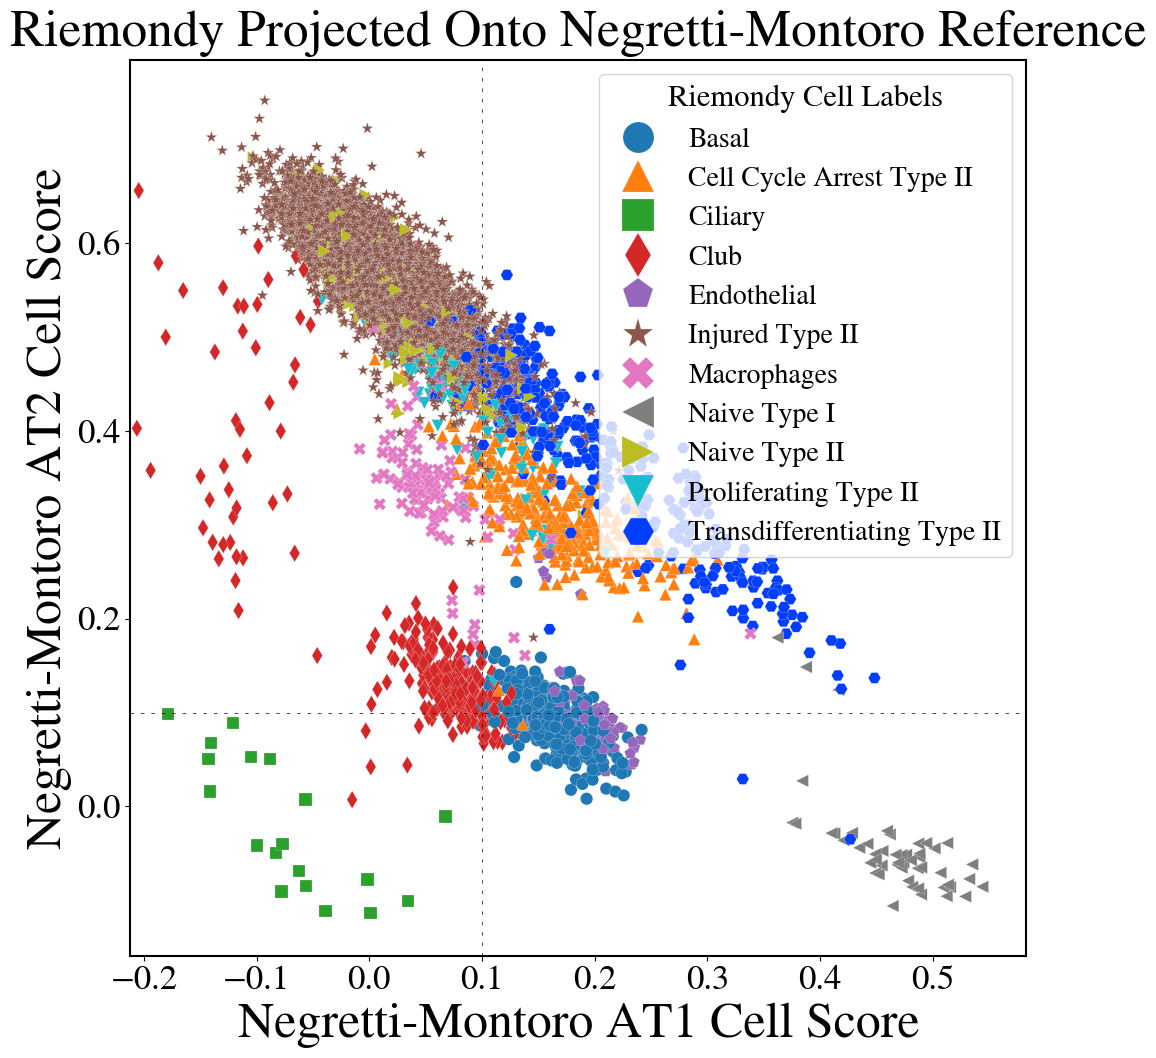

In [54]:
# Make 2D plot against basis
ax = SimilarityHelper.plotTwo(Riemondy, "Negretti-Montoro", 'AT1', 'AT2')

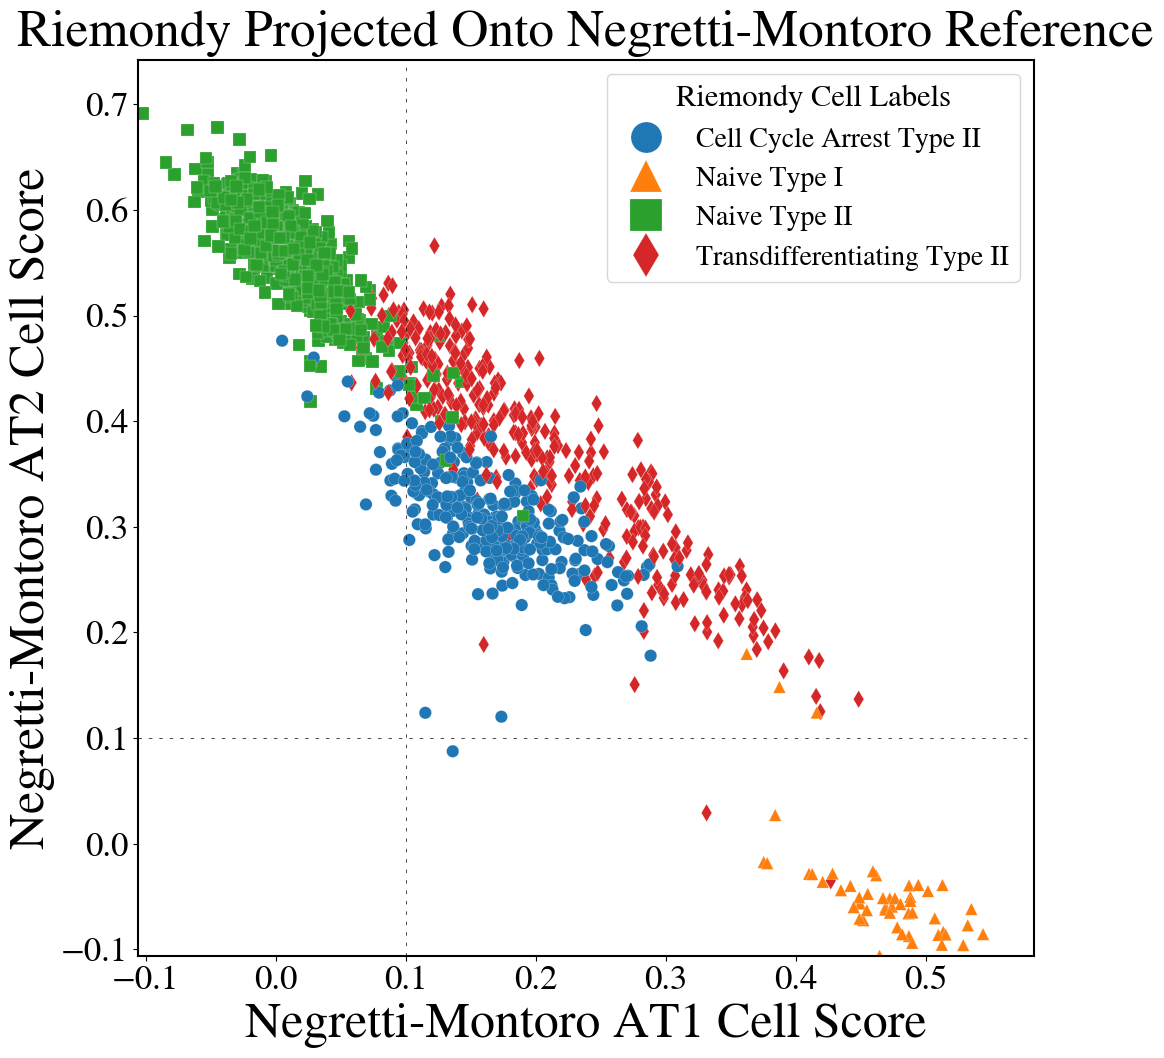

In [58]:
# Now plot with just the preset of features we care about. You can adjust this by setting your own inclusion criteria, or by adjusting the contents of toKeep
includeCriteria = Riemondy.annotations.isin(["Naive Type I", "Naive Type II", "Transdifferentiating Type II", "Cell Cycle Arrest Type II"])
ax = SimilarityHelper.plotTwo(Riemondy, "Negretti-Montoro", 'AT1', 'AT2', includeCriteria=includeCriteria)

In [ ]:
# Now repeat with more parameters
ax = SimilarityHelper.plotTwo(Riemondy, "Negretti-Montoro", "AT1", "AT2",
         includeCriteria=includeCriteria, DPI=150,
         title="", axisFontSize=20, source="ggplot2", maxLabelCount=500,
         figX=8, figY=8, markerSize=30, supervisedContour=True, #outFile="../results/MyFigure.png"
)

## Add new dataset or modify starting parameters

In [2]:
## Add dataset with prompts to guide you
TopObject.dynamicAddDataset(summaryFile=datasetCollection)
## See the CrossPlatformConversions folder for how to generate the AnnData (.h5ad) file needed from a Seurat file


Assign name. Enter a name to describe your dataset (if updating existing entry, choose the same name): LungMAP
Assign filePath. Enter the file path corresponding to the anndata object (.h5ad) for your dataset: /restricted/projectnb/crem-trainees/Kotton_Lab/Eitan/OutsidePaperObjects/AnnData/LungMAP.h5ad
Assign cellTypeColumn. Enter the title of the column containing cell type annotations: celltype_level3
Assign toKeep. Press Y to enter a list of cell types that you may filter to later or press Enter to skip: Y
Enter a cell type to include in filtering or press Enter to continue Basal
Enter a cell type to include in filtering or press Enter to continue Suprabasal
Enter a cell type to include in filtering or press Enter to continue AT2
Enter a cell type to include in filtering or press Enter to continue AT1
Enter a cell type to include in filtering or press Enter to continue Ciliated
Enter a cell type to include in filtering or press Enter to continue RAS
Enter a cell type to include in f

Writing updated file...


## Plot gene expression

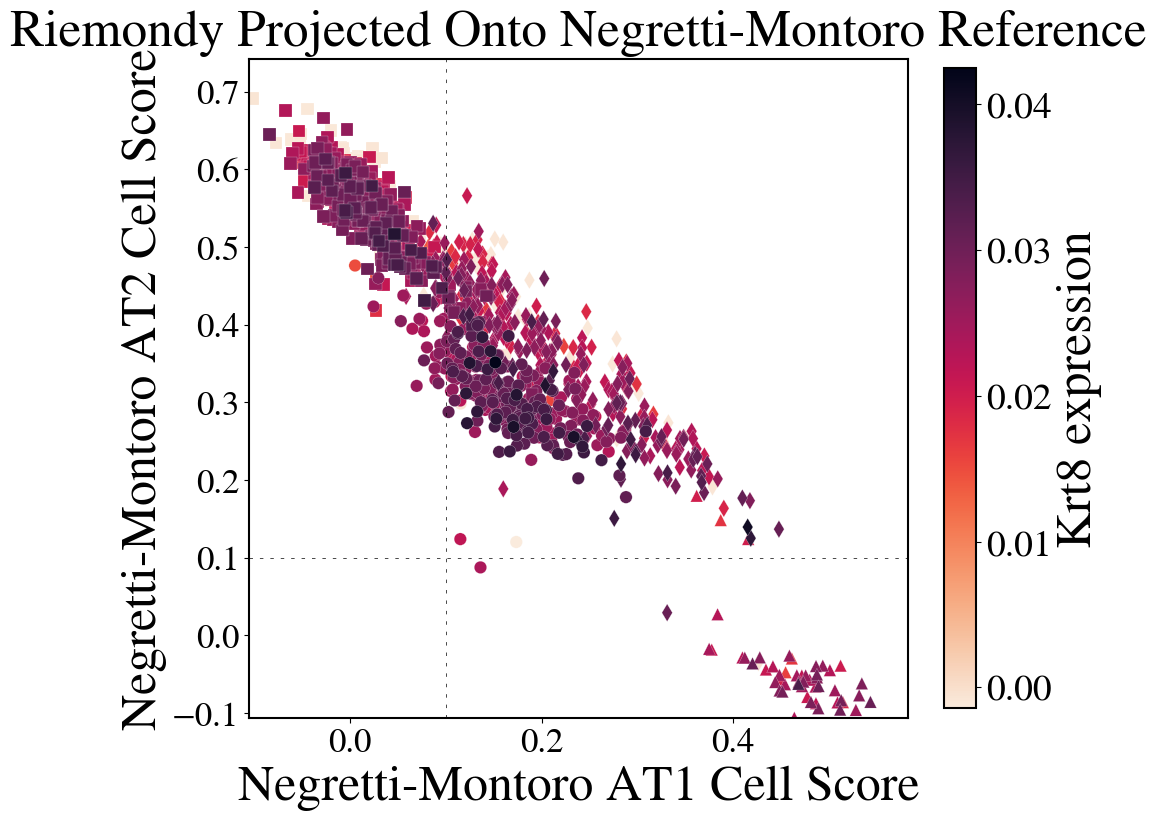

In [59]:
# You can do this option with plotTwo by simply passing in the gene of interest (case sensitive) to the gene parameter
# Note that the cells are ordered such that highest expressions are stacked on top; this can be toggled by setting randomOrder to True
ax = SimilarityHelper.plotTwo(Riemondy, "Negretti-Montoro", 'AT1', 'AT2', gene='Krt8', includeCriteria=includeCriteria)

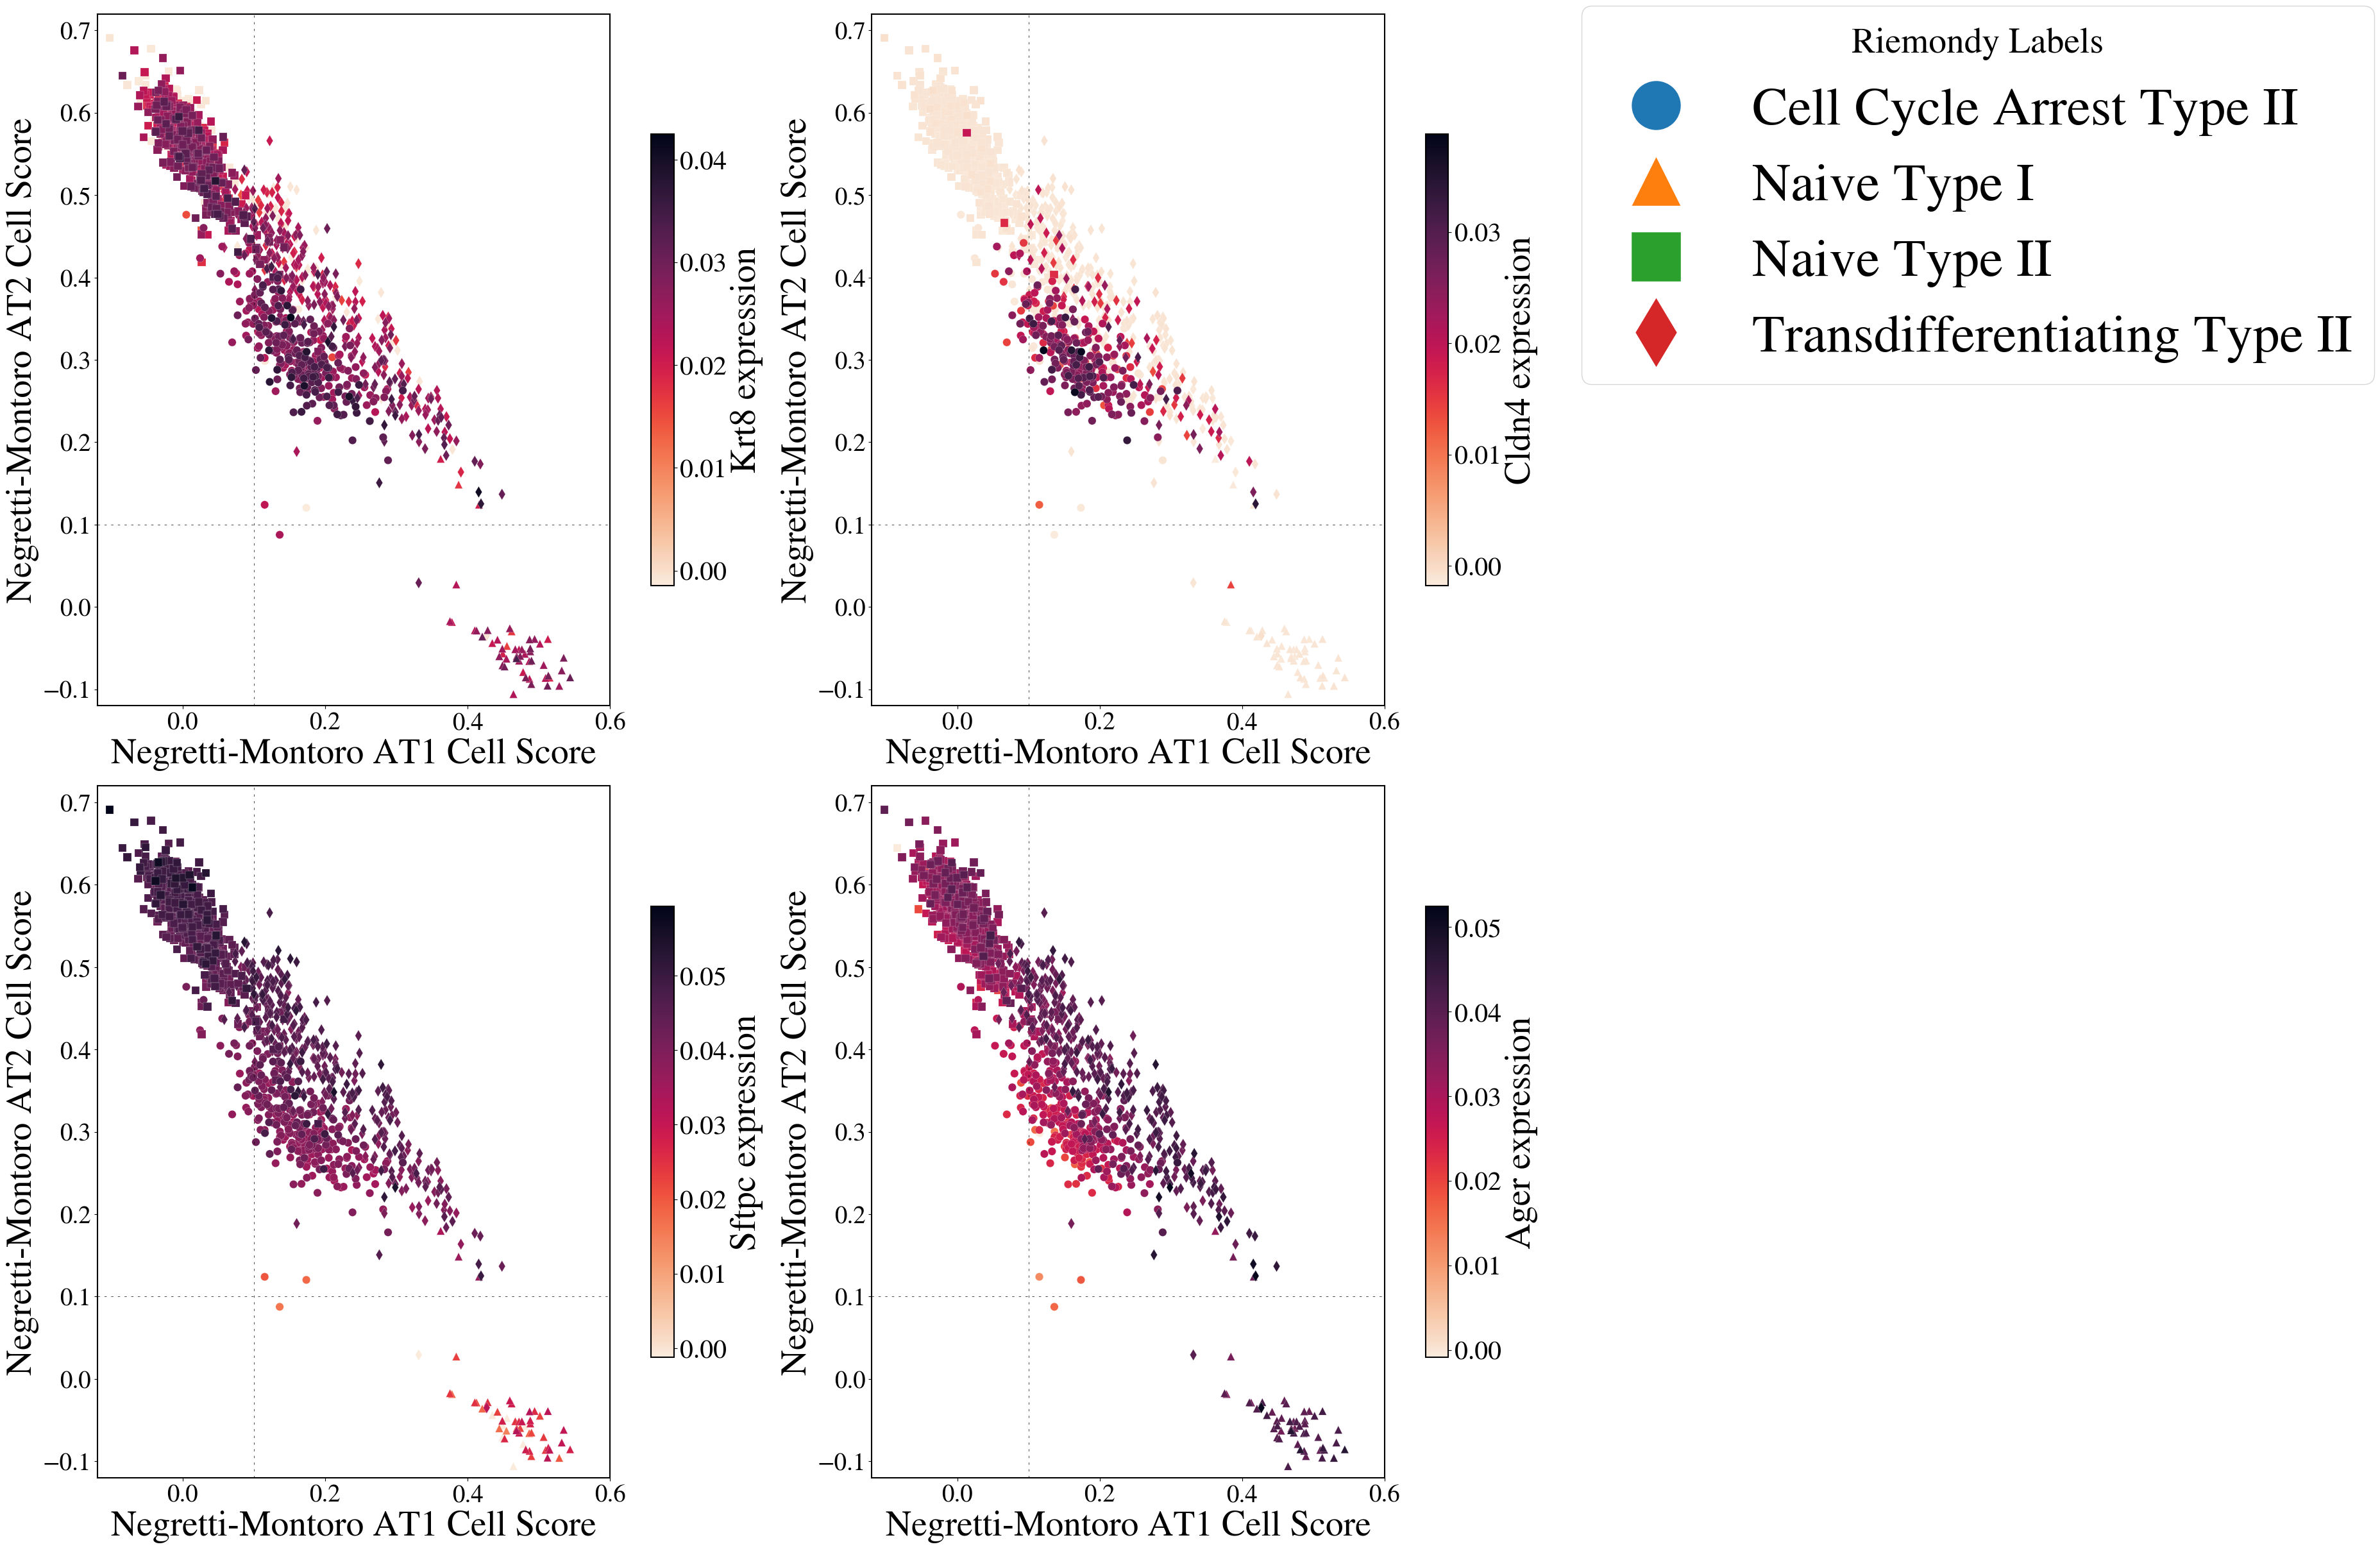

In [45]:
SimilarityHelper.plotMultipleGenes(Riemondy, "Negretti-Montoro", 'AT1', 'AT2', ['Krt8', 'Cldn4', 'Sftpc', 'Ager'], includeCriteria=includeCriteria)

## Plot boxplot of desired features of source against relevant features of basis

Similarity map built!


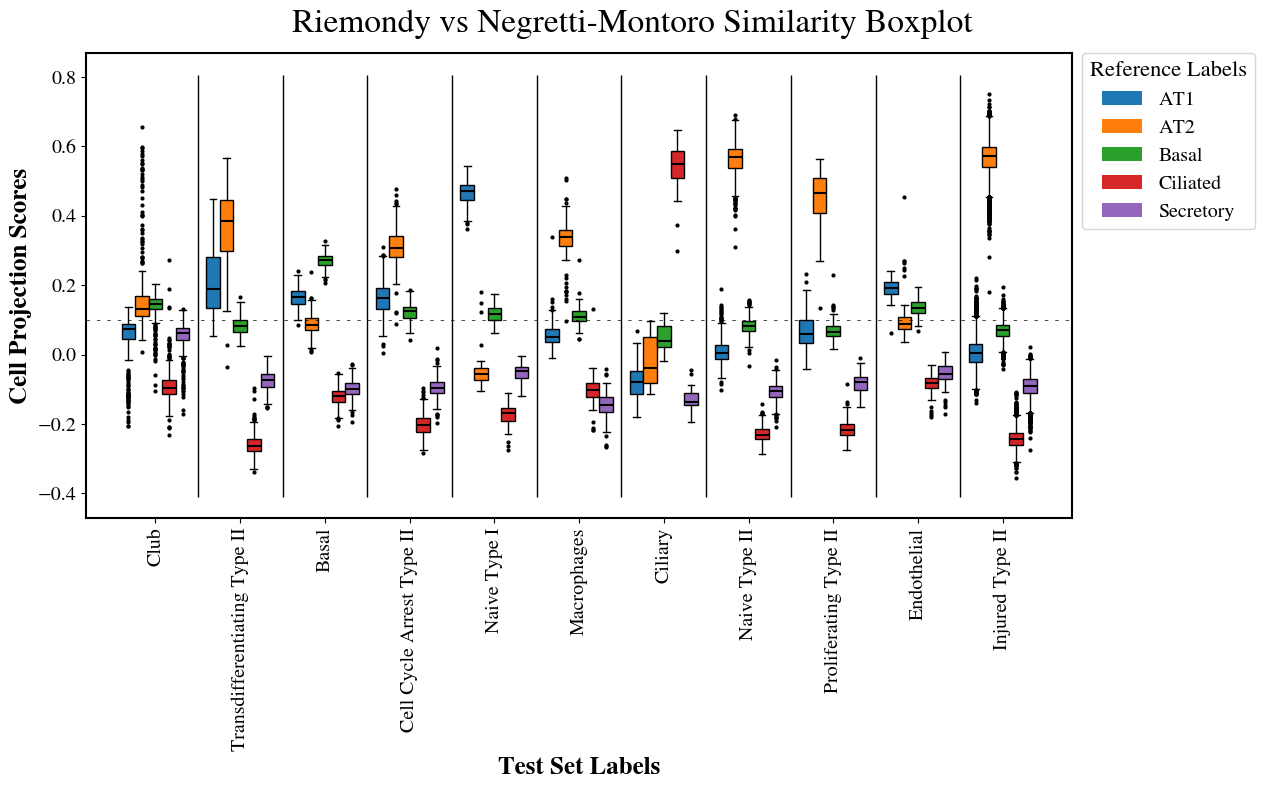

In [46]:
# First step: Create map of basis labels to the projections of cells with each source label onto said basis labels
RiemondySimilarityMap = SimilarityHelper.getMatchingProjections(Riemondy, "Negretti-Montoro")

# Second step: Set basic parameters like plot size and title and generate boxplot
SimilarityHelper.similarityBoxplot(RiemondySimilarityMap, title="Riemondy vs Negretti-Montoro Similarity Boxplot")

Similarity map built!


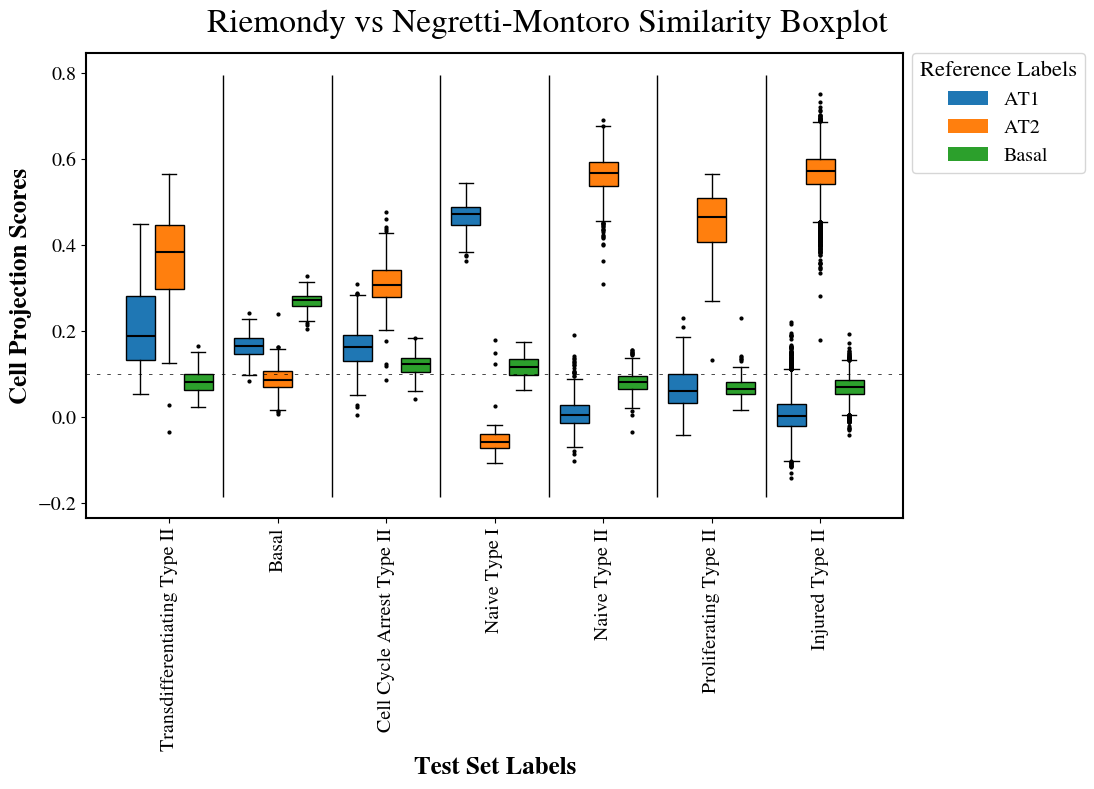

In [49]:
# It can help a lot to specify which features you are interested in for the source and basis
basisKeep = ['AT1', 'AT2', 'Basal']
RiemondySimilarityMap = SimilarityHelper.getMatchingProjections(Riemondy, "Negretti-Montoro", basisKeep=basisKeep, testKeep=Riemondy.toKeep)
SimilarityHelper.similarityBoxplot(RiemondySimilarityMap, title="Riemondy vs Negretti-Montoro Similarity Boxplot")

## Plot over multiple time points

In [50]:
# To do this, you just need to have a time column appropriately identified in your dataset. We'll load such a dataset
# Data processing can be very slow. It can help to filter beforehand, as done here with keep=True to only include types listed in toKeep
bibek = TopObject.TopObject("Bibek", keep=True)
bibek.project(mouseBasis, "Negretti-Montoro")

Setting AnnData object...
Setting AnnData...
Setting metadata and df...
Setting AnnData...
Setting metadata and df...
Finished filtering!
Processing scTOP data...
Done processing!
Finished setup!
Projecting onto basis...
Finished projecting! 1356 genes were in both the source and basis.


,AAACCCACAACTCCCT_1_1,AAACCCACATCTAACG_1_1,AAACGAAGTCACCTTC_1_1,AAACGAAGTCACTCGG_1_1,AAACGAATCGTGCACG_1_1,AAACGCTAGATAACGT_1_1,AAACGCTTCACTGAAC_1_1,AAAGAACTCGGTAACT_1_1,AAAGGATGTCCGGACT_1_1,AAAGGATTCGTTCTGC_1_1,...,TTTGACTAGTAATTGG-1_8,TTTGACTGTAGTACGG-1_8,TTTGACTTCTGCTCTG-1_8,TTTGGAGCACAAAGTA-1_8,TTTGGTTCACCCTATC-1_8,TTTGGTTTCGCTAATG-1_8,TTTGTTGAGGAATGTT-1_8,TTTGTTGCATGACCCG-1_8,TTTGTTGTCGAACCAT-1_8,TTTGTTGTCTTGTGCC-1_8
AT1,0.061339,0.014587,0.254044,0.024117,0.585087,-0.043331,0.017598,-0.005240,0.021494,0.005493,...,-0.133198,0.313244,0.513952,-0.059106,0.473328,-0.011536,0.037599,0.039042,0.571015,0.026198
Ciliated,-0.301285,-0.242144,-0.232238,-0.277750,-0.244698,-0.281401,-0.253896,-0.284320,-0.294619,-0.256828,...,0.742707,-0.333451,-0.240753,-0.242688,-0.110834,-0.255241,-0.284296,-0.284591,-0.256143,-0.291189
AT2,0.541989,0.549333,0.271583,0.585607,-0.097336,0.641174,0.583673,0.643487,0.581213,0.558274,...,-0.051399,0.325431,-0.022475,0.601414,0.011673,0.593082,0.576848,0.554422,-0.080101,0.582551
Secretory,-0.060444,-0.072214,-0.056689,-0.105878,-0.064511,-0.070930,-0.071130,-0.079706,-0.064838,-0.103477,...,-0.199467,-0.060238,-0.104327,-0.079868,-0.211670,-0.066875,-0.086657,-0.090613,-0.027867,-0.078897
Basal,0.050076,0.036833,0.054044,0.055308,0.080090,0.041689,0.026089,0.032415,0.040304,0.074414,...,-0.028562,0.059910,0.126141,0.062497,0.095442,0.020227,0.051986,0.065365,0.068626,0.067332


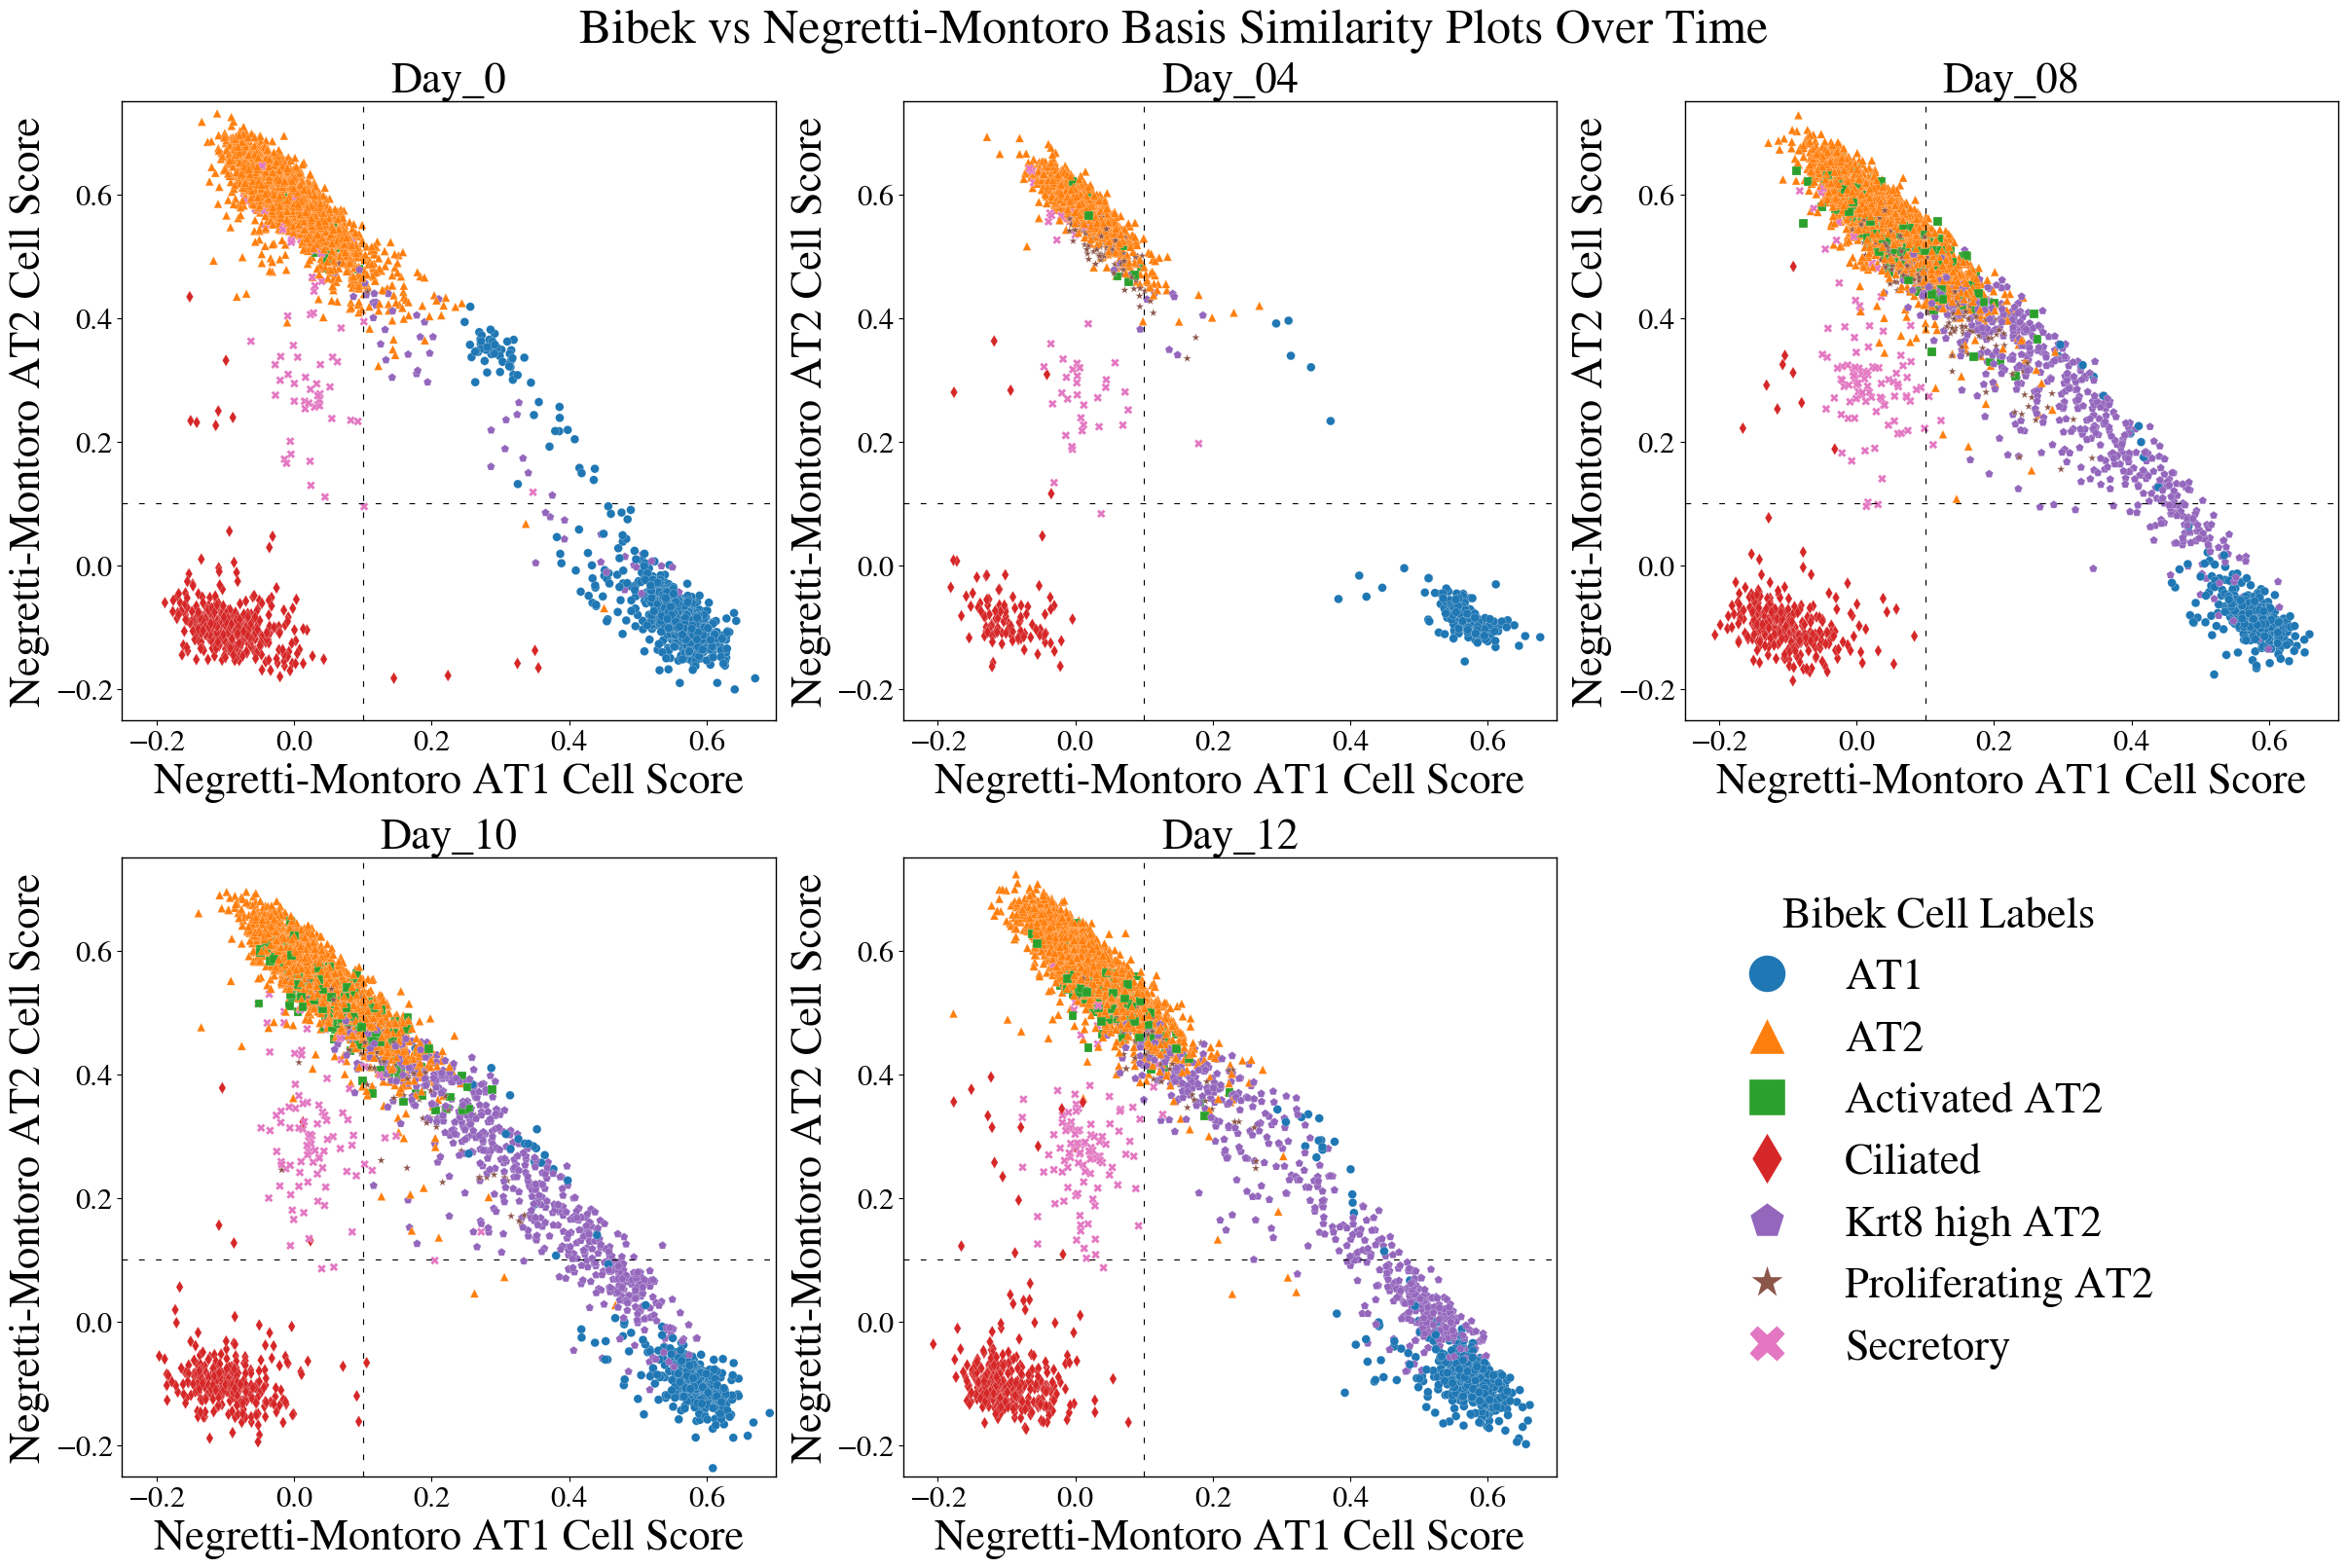

In [53]:
# So long as the time information was properly uploaded to the TopObject, you're set to run with no changes
SimilarityHelper.plotTwoMultiple(bibek, "Negretti-Montoro", 'AT1', 'AT2',
                                 title="Bibek vs Negretti-Montoro Basis Similarity Plots Over Time"
)